In [1]:
!pwd

/mnt/d/blog_in_progress/covalent_docking_VS/IKZF2


In [1]:
# conda vina env
import os
import subprocess
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS
from rdkit.Chem import rdDistGeom
from rdkit.Chem import rdChemReactions
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem.EnumerateStereoisomers import EnumerateStereoisomers
from openbabel import openbabel as ob
from pymol import cmd

In [ ]:
mol_list = []
with Chem.SDMolSupplier('covalent_cereblon_binders_final_clean_inc_sulf_long.sdf') as suppl:
    for mol in suppl:
        if mol is not None:
            mol_list.append(mol)
print(f'Number of molecules loaded: {len(mol_list)}')
smiles_list = [Chem.MolToSmiles(mol) for mol in mol_list]

In [ ]:
def All_Smiles_To_Covalent_Adducts_sdf(smiles_list, saved_conf_count=50, output_folder_path="cov_ligands"):
    ligand_sdf_path_list = []    
    try:
        os.makedirs(output_folder_path, exist_ok=True)
        all_isomers = []
        Histidine_fluorosulf_addition_smarts = (
            "[#9:0]-[#16:1](=[#8:2])(=[#8:3])-[*:4]>>[#6]-[#6]-[#6]1:[#7]:[#6]:[#7](-[#16:1](=[#8:2])(=[#8:3])-[*:4]):[#6]:1"
        )
        rxn_1 = rdChemReactions.ReactionFromSmarts(Histidine_fluorosulf_addition_smarts)
        rxn_2 = None
        rxn_3 = None
    
        for i in smiles_list:
            ligand_nonc = Chem.MolFromSmiles(i)
            Chem.SanitizeMol(ligand_nonc)
            ligand_nonc_isomers = list(EnumerateStereoisomers(ligand_nonc))
            for ii in ligand_nonc_isomers:
                try:
                    ligand_cov = rxn_1.RunReactants((ii,))[0][0]
                    Chem.SanitizeMol(ligand_cov)
                    Chem.AssignStereochemistry(
                        ligand_cov, force=True, flagPossibleStereoCenters=True
                    )
                    ligand_cov_isomers = list(EnumerateStereoisomers(ligand_cov))
                    for iii in ligand_cov_isomers:
                        all_isomers.append(iii)
                    if all_isomers:
                        print(f'molecule smiles {i} prepared for histidine fluorosulf addition successfully')
                    else:
                        raise ValueError(f'histidine fluorosulf addition failed for {i}')
                except:
                    try:
                        ligand_cov = rxn_2.RunReactants((ii,))[0][0]
                        Chem.SanitizeMol(ligand_cov)
                        Chem.AssignStereochemistry(
                            ligand_cov, force=True, flagPossibleStereoCenters=True
                        )
                        ligand_cov_isomers = list(EnumerateStereoisomers(ligand_cov))
                        for iii in ligand_cov_isomers:
                            all_isomers.append(iii)
                        if all_isomers:
                            print('None')
                        else:
                            raise ValueError('None')
    
                    except:
                        ligand_cov = rxn_3.RunReactants((ii,))[0][0]
                        Chem.SanitizeMol(ligand_cov)
                        Chem.AssignStereochemistry(
                            ligand_cov, force=True, flagPossibleStereoCenters=True
                        )
                        ligand_cov_isomers = list(EnumerateStereoisomers(ligand_cov))
                        for iii in ligand_cov_isomers:
                            all_isomers.append(iii)
                        if all_isomers:
                            print('None')
                        else:
                            raise ValueError('None')
                            
        print(f'Total number of isomers generated: {len(all_isomers)}')

        ps = rdDistGeom.ETKDGv3()
        ps.numThreads = 16
        
        for i, isomer in enumerate(all_isomers):
            energy_dict = {}  # conf_id as key; non_conc, energy as values
            Chem.SanitizeMol(isomer)
            #display(Draw.MolToImage(isomer, size=(300, 300)))
            isomer_H = Chem.AddHs(isomer)
            #display(Draw.MolToImage(isomer_H, size=(300, 300)))
            AllChem.EmbedMolecule(isomer_H, useRandomCoords=True, maxAttempts=1000)
            AllChem.EmbedMultipleConfs(isomer_H, 50, ps)
            try:
                res = AllChem.MMFFOptimizeMoleculeConfs(isomer_H, maxIters=1000)
                for x, y in enumerate(res):
                    energy_dict[x] = y
        
                sorted_energy_dict = {
                    k: v for k, v in sorted(energy_dict.items(), key=lambda item: item[1][-1])
                }
                #keeping multiple minimised conformers
                pre_conf_id_list = []
                for a, b in sorted_energy_dict.items():
                    if b[0] == 0:
                        pre_conf_id = a
                        pre_conf_id_list.append(a)
                        if len(pre_conf_id_list) >= saved_conf_count:
                            break

                ligand_sdf_path = os.path.join(output_folder_path, f"ligand_{i}.sdf")
                ligand_sdf_path_list.append(ligand_sdf_path)
                writer = Chem.SDWriter(ligand_sdf_path)
                isomer_noH = Chem.RemoveAllHs(isomer_H)
                for pre_conf_id in pre_conf_id_list: 
                    writer.write(isomer_noH, confId=pre_conf_id)
                writer.close()
            except:
                print(f'No conformers were minimized successfully for isomer {i}')
                continue
        
    except:
        print(f"Error occurred")
        print(f"Returning any existing SDF files in {output_folder_path}")
        if os.path.exists(output_folder_path):
            ligand_sdf_path_list = [os.path.join(output_folder_path, filename) for filename in os.listdir(output_folder_path) if filename.endswith('.sdf')]
        else:
            ligand_sdf_path_list = []

    return ligand_sdf_path_list

All_Smiles_To_Covalent_Adducts_sdf(smiles_list, saved_conf_count=5, output_folder_path="cov_ligands")

In [4]:
def split_cocrystal_structure(
    input_pdb_path, output_sdf_path, output_pdb_path
):
    cmd.delete("all")
    cmd.load(input_pdb_path)
    cmd.remove("all and hydro")
    cmd.select("selection_ligand", "org.")
    cmd.extract("LG", "selection_ligand")
    #cmd.h_add("LG")
    cmd.save(output_sdf_path, "LG", format="xyz")
    #cmd.select("selection_metal", "ino.")
    #cmd.remove("selection_metal")
    cmd.save(output_pdb_path, input_pdb_path.split("/")[-1].split(".")[-2])
    cmd.delete("all")

#This optimisse ligand geometry too much, better to use ob
from openbabel import pybel
def convert_xyz_to_sdf(input_path, output_path):
    mol = next(pybel.readfile("xyz", input_path))
    mol.OBMol.ConnectTheDots()
    mol.OBMol.PerceiveBondOrders()
    mol.addh()
    mol.localopt(forcefield="mmff94", steps=500)
    mol.write("sdf", output_path, overwrite=True)
    print(f"Successfully saved {output_path}")
#
for i in ['7LPS', '7U8F']:
    subprocess.run('mkdir -p '+i, shell=True, check=True)
    split_cocrystal_structure(
        input_pdb_path=f"{i}.pdb",
        output_sdf_path=f"{i}/{i}_ligand.xyz",
        output_pdb_path=f"{i}/{i}_protein.pdb",
    )

In [ ]:
def convert_xyz_to_sdf(input_xyz_path, output_sdf_path_noH, output_sdf_path_H):
    obConversion = ob.OBConversion()
    obConversion.SetInAndOutFormats("xyz", "sdf")
    mol = ob.OBMol()
    obConversion.ReadFile(mol, input_xyz_path)
    mol.ConnectTheDots()
    mol.PerceiveBondOrders()
    mol.AddHydrogens()
    obConversion.WriteFile(mol, output_sdf_path_noH)
    cmd.delete("all")
    cmd.load(output_sdf_path_noH)
    cmd.h_add("all")
    cmd.save(output_sdf_path_H)
    cmd.delete("all")
#if ligand contain Chlorine atom, make sure xyz atom name is Cl rather than CL
for i in ['7LPS', '7U8F']:
    convert_xyz_to_sdf(
        input_xyz_path=f"{i}/{i}_ligand.xyz",
        output_sdf_path_noH=f"{i}/{i}_ligand_ob_noH.sdf",
        output_sdf_path_H=f"{i}/{i}_ligand_ob_H.sdf",
    )

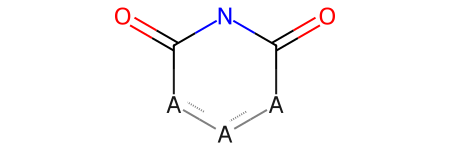

In [5]:
imide_smarts_new = "[!#1]1([!#1][!#1]-[#6](-[#7]-[#6]-1=[#8])=[#8])"
imide = Chem.MolFromSmarts(imide_smarts_new)
imide

In [2]:
def get_mcs_rmsd(query_sdf_path, ref_sdf_path, aligned_sdf_path, aligned=True, cutoff=2.0):

    if not os.path.exists(query_sdf_path):
        print(f"{query_sdf_path} does not exist, skipping...")
        return None, None
    
    confs = []
    # check the SMILES to verify aromaticity (lowercase atoms like 'c1ccccc1' indicate aromaticity)
    with Chem.SDMolSupplier(query_sdf_path, removeHs=True, sanitize=True) as suppl_query:
        for conf in suppl_query:
            if conf is None: continue
            #print(f"Query SMILES: {Chem.MolToSmiles(conf)}") 
            #display(Draw.MolToImage(conf))
            confs.append(conf)
            
    # Load reference molecule from XYZ file (rdkit suggle with this... so I use sdf converted by obabel)
    #ref_mol = Chem.MolFromXYZFile(ref_xyz_path)
    #display(Draw.MolToImage(ref_mol))
    #rdDetermineBonds.DetermineBondOrders(ref_mol, charge=0)    
    #print(f"Reference SMILES: {Chem.MolToSmiles(ref_mol)}")
    #display(Draw.MolToImage(ref_mol))

    with Chem.SDMolSupplier(ref_sdf_path, removeHs=True, sanitize=True) as suppl_ref:
        ref_mol = suppl_ref[0]
        #print(f"Reference SMILES: {Chem.MolToSmiles(ref_mol)}")
        #display(Draw.MolToImage(ref_mol))
        
    mcs = rdFMCS.FindMCS([confs[0], ref_mol], completeRingsOnly=True, ringMatchesRingOnly=False)
    patt = Chem.MolFromSmarts(mcs.smartsString)
    #print(mcs.smartsString)

    #check patt contains imide
    imide_smarts_new = "[!#1]1([!#1][!#1]-[#6](-[#7]-[#6]-1=[#8])=[#8])"
    imide_mol = Chem.MolFromSmarts(imide_smarts_new)
    if not patt.HasSubstructMatch(imide_mol):
        print("Warning: auto MCS does not contain a cyclic imide group, use defined cyclic imide as MCS instead")
        patt = imide_mol
    #display(Draw.MolToImage(patt))
    refMatch = ref_mol.GetSubstructMatch(patt)

    rms_min = None
    best_conf_id = None
    for i, conf in enumerate(confs):
        mv = conf.GetSubstructMatch(patt)
        if not mv:
            print(f"{query_sdf_path} does not contain the MCS, skipping...")
            return None, None
        if aligned == False:
            rms = AllChem.CalcRMS(conf, ref_mol, map=[list(zip(mv, refMatch))])
        else:
            rms = AllChem.AlignMol(conf, ref_mol, atomMap=list(zip(mv, refMatch)))
        if (rms_min is None) or (rms < rms_min):
            rms_min = rms
            best_conf_id = i

    if rms_min <= cutoff:
        with Chem.SDWriter(aligned_sdf_path) as writer:
            conf_with_hs = Chem.AddHs(confs[best_conf_id], addCoords=True)
            conf_with_hs.SetProp("_RMSD_MCS_to_ref", str(rms_min))
            writer.write(conf_with_hs)
        print(f"{aligned_sdf_path} is best valid conformation ID: {best_conf_id} with MCS RMSD: {rms_min} to {ref_sdf_path}")
        return best_conf_id, rms_min
    else:
        print(f"No valid conformation found with MCS RMSD <= {cutoff} A for {query_sdf_path} against {ref_sdf_path}")
        return None, None

In [ ]:
for pdb in ['7LPS', '7U8F']:
    for i in range(7345):
        get_mcs_rmsd(
            query_sdf_path=f"cov_ligands/ligand_{i}.sdf",
            ref_sdf_path=f"{pdb}/{pdb}_ligand_ob_H.sdf",
            aligned_sdf_path=f"cov_ligands/ligand_{i}_mcs_aligned_to_{pdb}.sdf",
            aligned=True,
            cutoff=2.0,
        )

cov_ligands/ligand_7344_mcs_aligned_to_7LPS.sdf is best valid conformation ID: 1 with MCS RMSD: 0.44346158776019623 to 7LPS/7LPS_ligand_ob_H.sdf
No valid conformation found with MCS RMSD <= 2.0 A for cov_ligands/ligand_7344.sdf against 7U8F/7U8F_ligand_ob_H.sdf


In [ ]:
#conda openfe env
from sys import stdout
import parmed as pmd
# OpenMM imports
import openmm.app as app
import openmm as mm
import openmm.unit as unit
from openmmforcefields.generators import SMIRNOFFTemplateGenerator
from openmm.app import PDBFile
# OpenFF-toolkit imports
from openff.toolkit import Molecule
from openff.toolkit import Topology as offTopology
from openff.units.openmm import to_openmm as offquantity_to_openmm
#pdbfixer import
from pdbfixer import PDBFixer
#biopython import
from Bio.PDB import PDBParser, PDBIO, Select

In [2]:
def fix_protein_structure(input_pdb_path, output_pdb_path):

    fixer = PDBFixer(filename=input_pdb_path)

    #chains = list(fixer.topology.chains())
    #numChains = len(chains)

    # Keep all chains
    #fixer.removeChains([0])

    # Remove heterogens including ion
    fixer.removeHeterogens(keepWater=False)
    # Perform the fixing steps
    fixer.findMissingResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(7.0)

    # Replace non-standard residues with standard ones
    fixer.findNonstandardResidues()
    fixer.nonstandardResidues = [(residue, 'ALA') for residue, replacement in fixer.nonstandardResidues]
    fixer.replaceNonstandardResidues()

    #Save the fixed structure
    with open(output_pdb_path, 'w') as f:
        PDBFile.writeFile(fixer.topology, fixer.positions, f)

fix_protein_structure(
    input_pdb_path="7LPS/7LPS_protein.pdb",
    output_pdb_path="7LPS/7LPS_protein_fixed.pdb",
)
fix_protein_structure(
    input_pdb_path="7U8F/7U8F_protein.pdb",
    output_pdb_path="7U8F/7U8F_protein_fixed.pdb",
)

In [2]:
def prep_protein_ligand_complex(protein_path, ligand_path, output_path, min_step):

    protein_pdb = app.PDBFile(protein_path)
    ligand_mol = Molecule.from_file(ligand_path)
    template_generator = SMIRNOFFTemplateGenerator(molecules=[ligand_mol], forcefield="openff-2.2.1.offxml")
    forcefield = app.ForceField('amber14-all.xml', 'implicit/gbn2.xml')
    forcefield.registerTemplateGenerator(template_generator.generator)

    modeller = app.Modeller(protein_pdb.topology, protein_pdb.positions)
    ligand_off_topology = offTopology.from_molecules([ligand_mol])
    ligand_omm_topology = ligand_off_topology.to_openmm()
    ligand_positions = offquantity_to_openmm(ligand_mol.conformers[0])
    modeller.add(ligand_omm_topology, ligand_positions)

    system = forcefield.createSystem(modeller.topology, nonbondedMethod=app.NoCutoff, constraints=app.HBonds)
    
    integrator = mm.LangevinIntegrator(300*unit.kelvin, 1/unit.picosecond, 0.002*unit.picoseconds)
    simulation = app.Simulation(modeller.topology, system, integrator)
    simulation.context.setPositions(modeller.positions)
    
    simulation.minimizeEnergy(maxIterations=min_step)

    positions = simulation.context.getState(getPositions=True).getPositions()
    
    with open(output_path, 'w') as f:
        app.PDBFile.writeFile(simulation.topology, positions, f)

for i in['7LPS', '7U8F']:
    prep_protein_ligand_complex(
        protein_path=f'{i}/{i}_protein_fixed.pdb',
        ligand_path=f'{i}/{i}_ligand_ob_H.sdf',
        output_path=f'{i}/{i}_protein_fixed_lig_prep.pdb',
        min_step=100,
    )

In [3]:
class NotHeteroSelect(Select):
    """
    Selection class to filter out heterogens (HETATM records).
    """
    def accept_residue(self, residue):
        # res_id[0] is the hetero-flag. 
        # ' ' means it is a standard amino acid or nucleotide.
        # 'W' is water, 'H_...' is a ligand/heterogen.
        return residue.get_id()[0] == ' '

def remove_heterogens(input_pdb, output_pdb):
    """
    Reads a PDB file and saves a new version containing only 
    standard residues (no ligands, ions, or water).
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', input_pdb)
    
    io = PDBIO()
    io.set_structure(structure)
    
    # Save using our custom filter
    io.save(output_pdb, NotHeteroSelect())
    print(f"Cleaned PDB saved to: {output_pdb}")

for i in ['7LPS', '7U8F']:
    remove_heterogens(f"{i}/{i}_protein_fixed_lig_prep.pdb", f"{i}/{i}_protein_clean.pdb")

Cleaned PDB saved to: 7LPS/7LPS_protein_clean.pdb
Cleaned PDB saved to: 7U8F/7U8F_protein_clean.pdb


In [1]:
#conda autodock env
import os
import subprocess
from rdkit import Chem
from multiprocessing import Pool

In [ ]:
def covalent_grid_prep(protein_dir_path, reactive_flexible_residue, reactive_atom_name, size=20):
    subprocess.run(
        f"mk_prepare_receptor.py \
                    --read_pdb *_clean.pdb \
                    -p receptor_rigid.pdbqt \
                    -g receptor_rigid.gpf \
                    --reactive_flexres {reactive_flexible_residue} \
                    --reactive_name {reactive_atom_name} \
                    --box_center_off_reactive_res \
                    --box_size {size} {size} {size} \
                    --allow_bad_res",
        cwd=protein_dir_path,
        shell=True,
    )
    
    new_lines = []
    with open(protein_dir_path + "/receptor_rigid.gpf", "r") as sfile:
        lines = sfile.readlines()
        for line in lines:
            if "receptor_rigid.Br.map" not in line:
                if "receptor_rigid.BR.map" not in line:
                    if "receptor_rigid.I.map" not in line:
                        if "receptor_rigid.Si.map" not in line:
                            if "receptor_rigid.B.map" not in line:
                                if "Br BR I Si B" not in line:
                                    new_lines.append(line)
                                else:
                                    new_lines.append(line.replace("Br BR I Si B", ""))
   
    with open(protein_dir_path + "/receptor_rigid_2.gpf", "w") as efile:
        efile.writelines(new_lines)
    
    rt = subprocess.run(
        f"autogrid4 -p receptor_rigid_2.gpf", cwd=protein_dir_path, shell=True
    )
    assert rt.returncode == 0, f"Autogrid returned error code: {rt.returncode}"

#large grid box to cover binding site
covalent_grid_prep('7LPS', 'B:6', 'HIS:NE2', size=25)
covalent_grid_prep('7U8F', 'B:6', 'HIS:NE2', size=25)

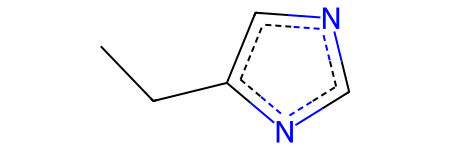

In [3]:
Chem.MolFromSmarts('C-C-c:1:n:c:n:c:1')

In [2]:
def autodock_covalent(receptor_dir_path, output_folder, ligand_input_sdf_path_glob, reactive_flexible_residue, nrun=20):
    
    if not os.path.exists(ligand_input_sdf_path_glob):
        return print(f'Ligand input SDF file {ligand_input_sdf_path_glob} does not exist, skipping docking for this ligand.')
    
    subprocess.run(f"mkdir {output_folder}", cwd = receptor_dir_path, shell = True)
    subprocess.run(f"mk_prepare_ligand.py \
                    -i {ligand_input_sdf_path_glob} \
                    --receptor *_clean.pdb \
                    --rec_residue {reactive_flexible_residue} \
                    --tether_smarts 'C-C-c:1:n:c:n:c:1'\
                    --tether_smarts_indices 1 2 \
                    -o {output_folder}/ligand.pdbqt", cwd = receptor_dir_path, shell = True)
                    #--multimol_prefix ligand \
                    #--multimol_outdir {output_folder}", cwd = receptor_dir_path, shell = True)
    
    subprocess.run(f"autodock_gpu_128wi \
                    -M receptor_rigid_rigid.maps.fld \
                    -F {output_folder}/ligand.pdbqt \
                    -nrun {nrun} \
                    -devnum 1", cwd = receptor_dir_path, shell = True)
    subprocess.run(f"mk_export.py {output_folder}/*.dlg -s {output_folder}/docked.sdf -k", cwd = receptor_dir_path, shell = True)

    return print(f'Docking completed for {ligand_input_sdf_path_glob} in {receptor_dir_path}')
#
def run_pipeline(args):
    res, pdb = args
    for i in range(7345):
        autodock_covalent(
            pdb,
            output_folder=f"ligand_{i}_docked",
            ligand_input_sdf_path_glob=f"/mnt/d/blog_in_progress/covalent_docking_VS/IKZF2/cov_ligands/ligand_{i}_mcs_aligned_to_{pdb}.sdf",
            reactive_flexible_residue=res,
        )
#
if __name__ == '__main__':
    pipelines = [('B:HIS:6', '7LPS'), ('B:HIS:6', '7U8F')]
    with Pool(2) as p:
        p.map(run_pipeline, pipelines)

Ligand input SDF file /mnt/d/blog_in_progress/covalent_docking_VS/IKZF2/cov_ligands/ligand_0_mcs_aligned_to_7U8F.sdf does not exist, skipping docking for this ligand.Ligand input SDF file /mnt/d/blog_in_progress/covalent_docking_VS/IKZF2/cov_ligands/ligand_0_mcs_aligned_to_7LPS.sdf does not exist, skipping docking for this ligand.

Ligand input SDF file /mnt/d/blog_in_progress/covalent_docking_VS/IKZF2/cov_ligands/ligand_1_mcs_aligned_to_7U8F.sdf does not exist, skipping docking for this ligand.Ligand input SDF file /mnt/d/blog_in_progress/covalent_docking_VS/IKZF2/cov_ligands/ligand_1_mcs_aligned_to_7LPS.sdf does not exist, skipping docking for this ligand.

Ligand input SDF file /mnt/d/blog_in_progress/covalent_docking_VS/IKZF2/cov_ligands/ligand_2_mcs_aligned_to_7LPS.sdf does not exist, skipping docking for this ligand.Ligand input SDF file /mnt/d/blog_in_progress/covalent_docking_VS/IKZF2/cov_ligands/ligand_2_mcs_aligned_to_7U8F.sdf does not exist, skipping docking for this ligand.

@> 6490 atoms and 1 coordinate set(s) were parsed in 0.03s.
@> 6577 atoms and 1 coordinate set(s) were parsed in 0.03s.


Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0
Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0
AutoDock-GPU version: v1.6-7-ga46ab564d2ac5f1a1523f65239b43505a1c29364

Running 1 docking calculation

Cuda device:                              NVIDIA GeForce RTX 5070 Laptop GPU
Available memory on device:               6912 MB (total: 8150 MB)

CUDA Setup time 2.694701s
(Thread 9 is setting up Job #1)
AutoDock-GPU version: v1.6-7-ga46ab564d2ac5f1a1523f65239b43505a1c29364

Running 1 docking calculation

Cuda device:                              NVIDIA GeForce RTX 5070 Laptop GPU
Available memory on device:               6912 MB (total: 8150 MB)

CUDA Setup time 2.694873s
(Thread 15 is setting up Job #1)

Running Job #1
    Using heuristics: (capped) number of evaluations set to 1259779
    Local-search chosen method is

@> 6577 atoms and 1 coordinate set(s) were parsed in 0.03s.
@> 6490 atoms and 1 coordinate set(s) were parsed in 0.03s.


Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0
Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0
AutoDock-GPU version: v1.6-7-ga46ab564d2ac5f1a1523f65239b43505a1c29364

Running 1 docking calculation

Cuda device:                              NVIDIA GeForce RTX 5070 Laptop GPU
Available memory on device:               6912 MB (total: 8150 MB)

CUDA Setup time 0.919231s
(Thread 4 is setting up Job #1)
AutoDock-GPU version: v1.6-7-ga46ab564d2ac5f1a1523f65239b43505a1c29364

Running 1 docking calculation

Cuda device:                              NVIDIA GeForce RTX 5070 Laptop GPU
Available memory on device:               6912 MB (total: 8150 MB)

CUDA Setup time 0.885711s
(Thread 4 is setting up Job #1)

Running Job #1
    Using heuristics: (capped) number of evaluations set to 1259779
    Local-search chosen method is:

...

@> 6577 atoms and 1 coordinate set(s) were parsed in 0.03s.
@> 6490 atoms and 1 coordinate set(s) were parsed in 0.03s.


Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0
Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0
AutoDock-GPU version: v1.6-7-ga46ab564d2ac5f1a1523f65239b43505a1c29364

Running 1 docking calculation

Cuda device:                              NVIDIA GeForce RTX 5070 Laptop GPU
Available memory on device:               6912 MB (total: 8150 MB)

CUDA Setup time 0.913679s
(Thread 6 is setting up Job #1)
AutoDock-GPU version: v1.6-7-ga46ab564d2ac5f1a1523f65239b43505a1c29364

Running 1 docking calculation

Cuda device:                              NVIDIA GeForce RTX 5070 Laptop GPU
Available memory on device:               6912 MB (total: 8150 MB)

CUDA Setup time 0.839337s
(Thread 14 is setting up Job #1)

Running Job #1
    Using heuristics: (capped) number of evaluations set to 1259779
    Local-search chosen method is

@> 6577 atoms and 1 coordinate set(s) were parsed in 0.03s.
@> 6490 atoms and 1 coordinate set(s) were parsed in 0.03s.


Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0
Input molecules processed: 1, skipped: 0
PDBQT files written: 1
PDBQT files not written due to error: 0
Input molecules with errors: 0


KeyboardInterrupt: 

In [3]:
#conda vina env
for pdb in ['7LPS', '7U8F']:
    for i in range(5276):
        get_mcs_rmsd(
            query_sdf_path=f"{pdb}/ligand_{i}_docked/docked.sdf",
            ref_sdf_path=f"{pdb}/{pdb}_ligand_ob_H.sdf",
            aligned_sdf_path=f"{pdb}/ligand_{i}_docked/docked_valid_pose.sdf",
            aligned=False,
            cutoff=2.0,
        )

No valid conformation found with MCS RMSD <= 2.0 A for 7LPS/ligand_0_docked/docked.sdf against 7LPS/7LPS_ligand_ob_H.sdf
No valid conformation found with MCS RMSD <= 2.0 A for 7LPS/ligand_1_docked/docked.sdf against 7LPS/7LPS_ligand_ob_H.sdf
No valid conformation found with MCS RMSD <= 2.0 A for 7LPS/ligand_2_docked/docked.sdf against 7LPS/7LPS_ligand_ob_H.sdf
No valid conformation found with MCS RMSD <= 2.0 A for 7LPS/ligand_3_docked/docked.sdf against 7LPS/7LPS_ligand_ob_H.sdf
No valid conformation found with MCS RMSD <= 2.0 A for 7LPS/ligand_4_docked/docked.sdf against 7LPS/7LPS_ligand_ob_H.sdf
No valid conformation found with MCS RMSD <= 2.0 A for 7LPS/ligand_5_docked/docked.sdf against 7LPS/7LPS_ligand_ob_H.sdf
No valid conformation found with MCS RMSD <= 2.0 A for 7LPS/ligand_6_docked/docked.sdf against 7LPS/7LPS_ligand_ob_H.sdf
No valid conformation found with MCS RMSD <= 2.0 A for 7LPS/ligand_7_docked/docked.sdf against 7LPS/7LPS_ligand_ob_H.sdf
No valid conformation found with

In [4]:
subprocess.run('mkdir -p final_docked_poses', shell=True, check=True)
for pdb in ['7LPS', '7U8F']:
    for i in range(5276):
        src = f'{pdb}/ligand_{i}_docked/docked_valid_pose.sdf'
        dst = f'final_docked_poses/{pdb}_ligand_{i}_docked_valid_pose.sdf'
        if os.path.exists(src):
            subprocess.run(
                f'cp {src} {dst}',
                shell=True,
                check=True,
            )